In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("NGO DataSet.csv")

Saving NGO DataSet.csv to NGO DataSet (2).csv


In [ ]:


df.head()

,Student_ID,Gender,Age,District,Program_Name,Attendance_Percentage,Pre_Test_Score,Post_Test_Score,Program_Cost,Enrollment_Date,Completion_Status,Outcome_Achieved
0,1,Female,18,Sambhal,Teacher Training,54,37,38.0,2000,2025-04-22,No,No
1,2,Male,13,Sambhal,Digital Literacy,92,45,64.0,1500,2025-01-26,Yes,Yes
2,3,Female,17,Amroha,Scholarship Support,48,57,55.0,1800,2025-04-06,No,No
3,4,Female,13,Sambhal,Digital Literacy,88,80,99.0,1500,2025-07-26,Yes,Yes
4,5,Female,13,Sambhal,Scholarship Support,82,63,76.0,1800,2025-11-14,Yes,Yes


In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Info:")
df.info()

Shape of Dataset:
(300, 12)

Column Names:
Index(['Student_ID', 'Gender', 'Age', 'District', 'Program_Name',
       'Attendance_Percentage', 'Pre_Test_Score', 'Post_Test_Score',
       'Program_Cost', 'Enrollment_Date', 'Completion_Status',
       'Outcome_Achieved'],
      dtype='object')

Data Types:
Student_ID                 int64
Gender                    object
Age                        int64
District                  object
Program_Name              object
Attendance_Percentage      int64
Pre_Test_Score             int64
Post_Test_Score          float64
Program_Cost               int64
Enrollment_Date           object
Completion_Status         object
Outcome_Achieved          object
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             300 non-null    int64  
 1   Gende

In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,3
Age,0
District,4
Program_Name,0
Attendance_Percentage,0
Pre_Test_Score,0
Post_Test_Score,5
Program_Cost,0
Enrollment_Date,0


In [ ]:
df["Gender"] = df["Gender"].fillna(
    df["Gender"].mode()[0]
)

In [ ]:
df["District"] = df["District"].fillna(
    df["District"].mode()[0]
)

In [ ]:
df["Post_Test_Score"] = df["Post_Test_Score"].fillna(
    df["Post_Test_Score"].median()
)

In [ ]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [ ]:
df["Score_Improvement"] = (
    df["Post_Test_Score"] -
    df["Pre_Test_Score"]
)

In [ ]:
df.head()

,Student_ID,Gender,Age,District,Program_Name,Attendance_Percentage,Pre_Test_Score,Post_Test_Score,Program_Cost,Enrollment_Date,Completion_Status,Outcome_Achieved,Score_Improvement
0,1,Female,18,Sambhal,Teacher Training,54,37,38.0,2000,2025-04-22,No,No,1.0
1,2,Male,13,Sambhal,Digital Literacy,92,45,64.0,1500,2025-01-26,Yes,Yes,19.0
2,3,Female,17,Amroha,Scholarship Support,48,57,55.0,1800,2025-04-06,No,No,-2.0
3,4,Female,13,Sambhal,Digital Literacy,88,80,99.0,1500,2025-07-26,Yes,Yes,19.0
4,5,Female,13,Sambhal,Scholarship Support,82,63,76.0,1800,2025-11-14,Yes,Yes,13.0


In [ ]:
df["Improvement_Percentage"] = (
    (df["Post_Test_Score"] -
     df["Pre_Test_Score"])
    /
    df["Pre_Test_Score"]
) * 100

In [ ]:
df.describe()

,Student_ID,Age,Attendance_Percentage,Pre_Test_Score,Post_Test_Score,Program_Cost,Score_Improvement,Improvement_Percentage
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,150.500000,15.873333,73.490000,53.966667,68.423333,1679.333333,14.456667,30.950050
std,86.746758,2.019294,16.056232,16.309062,17.639765,245.575337,9.920156,26.915417
min,1.000000,13.000000,45.000000,25.000000,27.000000,1400.000000,-2.000000,-5.128205
25%,75.750000,14.000000,60.000000,38.000000,56.000000,1400.000000,6.750000,10.399923
50%,150.500000,16.000000,74.000000,55.000000,69.000000,1800.000000,13.000000,26.766169
75%,225.250000,18.000000,86.250000,67.250000,81.000000,2000.000000,22.000000,42.857143
max,300.000000,19.000000,100.000000,80.000000,100.000000,2000.000000,42.000000,155.555556


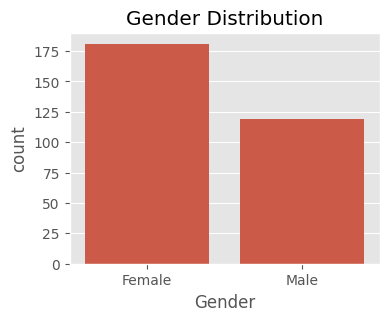

In [ ]:
plt.figure(figsize=(4,3))

sns.countplot(
    x="Gender",
    data=df
)

plt.title("Gender Distribution")
plt.show()

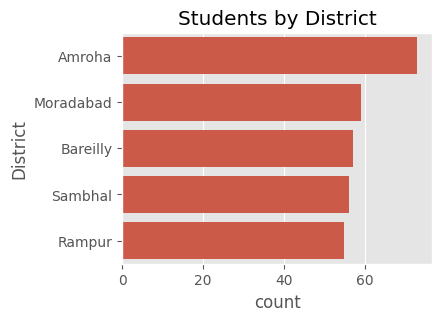

In [ ]:
plt.figure(figsize=(4,3))

sns.countplot(
    y="District",
    data=df,
    order=df["District"].value_counts().index
)

plt.title("Students by District")
plt.show()

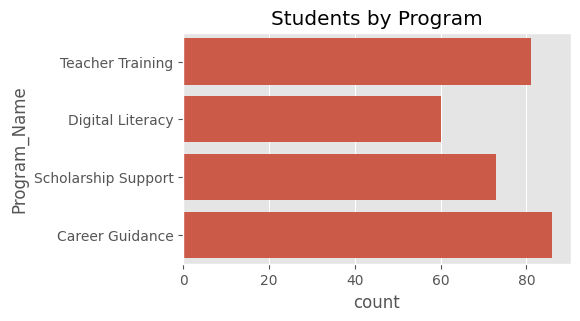

In [ ]:
plt.figure(figsize=(5,3))

sns.countplot(
    y="Program_Name",
    data=df
)

plt.title("Students by Program")
plt.show()

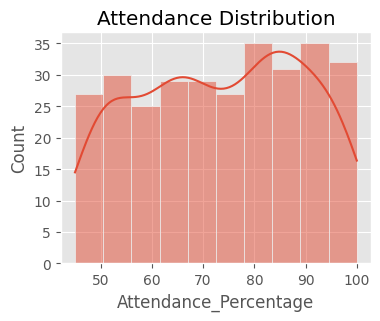

In [ ]:
plt.figure(figsize=(4,3))

sns.histplot(
    df["Attendance_Percentage"],
    bins=10,
    kde=True
)

plt.title("Attendance Distribution")
plt.show()

In [ ]:
df["Attendance_Bin"] = pd.cut(
    df["Attendance_Percentage"],
    bins=[0, 25, 50, 75, 100],
    labels=["0-25", "25-50", "50-75", "75-100"],
    include_lowest=True
)

In [ ]:
df.head()

,Student_ID,Gender,Age,District,Program_Name,Attendance_Percentage,Pre_Test_Score,Post_Test_Score,Program_Cost,Enrollment_Date,Completion_Status,Outcome_Achieved,Score_Improvement,Improvement_Percentage,Attendance_Bin
0,1,Female,18,Sambhal,Teacher Training,54,37,38.0,2000,2025-04-22,No,No,1.0,2.702703,50-75
1,2,Male,13,Sambhal,Digital Literacy,92,45,64.0,1500,2025-01-26,Yes,Yes,19.0,42.222222,75-100
2,3,Female,17,Amroha,Scholarship Support,48,57,55.0,1800,2025-04-06,No,No,-2.0,-3.508772,25-50
3,4,Female,13,Sambhal,Digital Literacy,88,80,99.0,1500,2025-07-26,Yes,Yes,19.0,23.750000,75-100
4,5,Female,13,Sambhal,Scholarship Support,82,63,76.0,1800,2025-11-14,Yes,Yes,13.0,20.634921,75-100


In [ ]:
attendance_impact = (
    df.groupby("Attendance_Bin")["Improvement_Percentage"]
      .mean()
      .reset_index()
)

attendance_impact

/tmp/ipykernel_2441/1447986311.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Attendance_Bin")["Improvement_Percentage"]


,Attendance_Bin,Improvement_Percentage
0,0-25,NaN
1,25-50,4.779568
2,50-75,18.138591
3,75-100,47.333948


In [ ]:
df["Attendance_Bin"].value_counts().sort_index()

,count
Attendance_Bin,
0-25,0
25-50,27
50-75,129
75-100,144


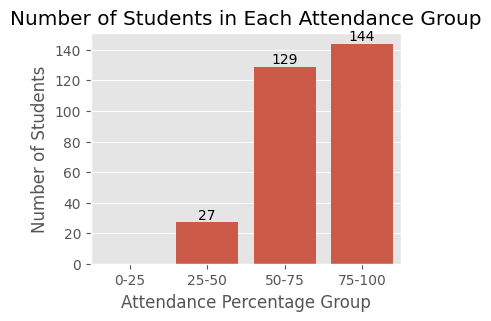

In [ ]:
plt.figure(figsize=(4,3))

ax = sns.countplot(
    data=df,
    x="Attendance_Bin"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Students in Each Attendance Group")
plt.xlabel("Attendance Percentage Group")
plt.ylabel("Number of Students")

plt.show()

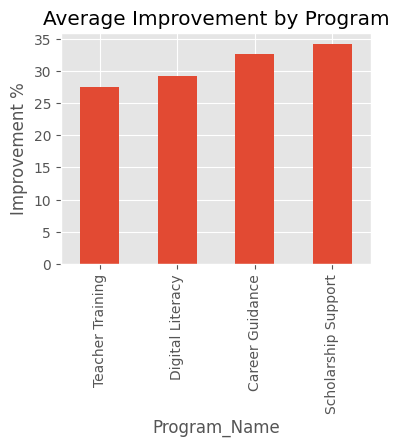

In [ ]:
program_perf = df.groupby(
    "Program_Name"
)["Improvement_Percentage"].mean()

program_perf.sort_values().plot(
    kind="bar",
    figsize=(4,3)
)

plt.title("Average Improvement by Program")
plt.ylabel("Improvement %")
plt.show()

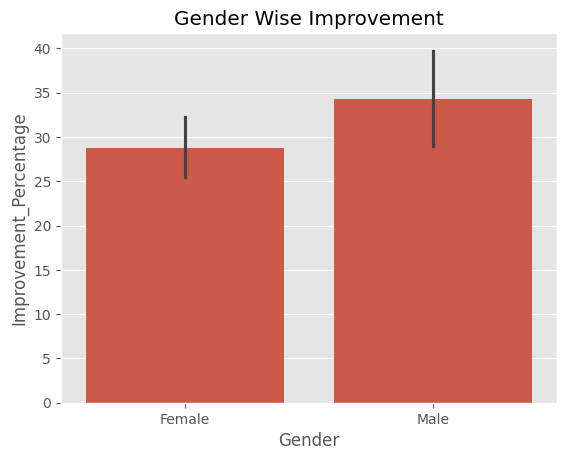

In [ ]:
sns.barplot(
    x="Gender",
    y="Improvement_Percentage",
    data=df
)

plt.title("Gender Wise Improvement")
plt.show()

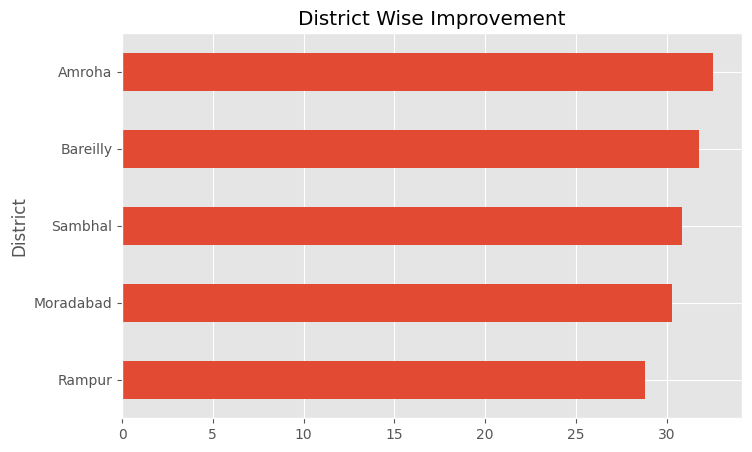

In [ ]:
district_perf = df.groupby(
    "District"
)["Improvement_Percentage"].mean()

district_perf.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("District Wise Improvement")
plt.show()

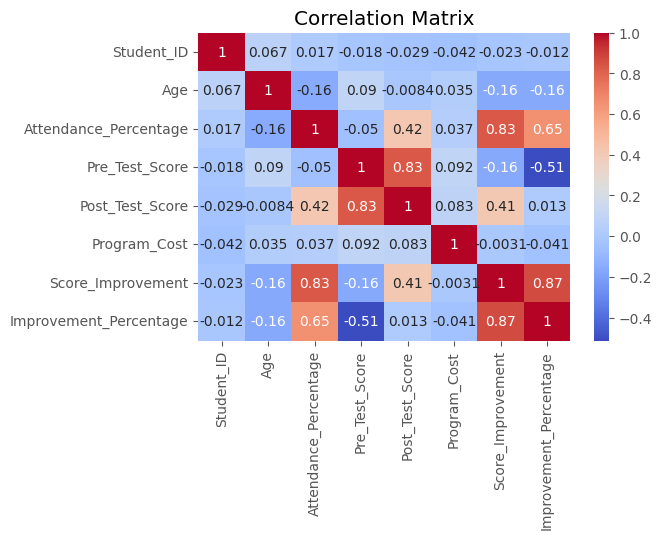

In [ ]:
plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes(include=np.number)
      .corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

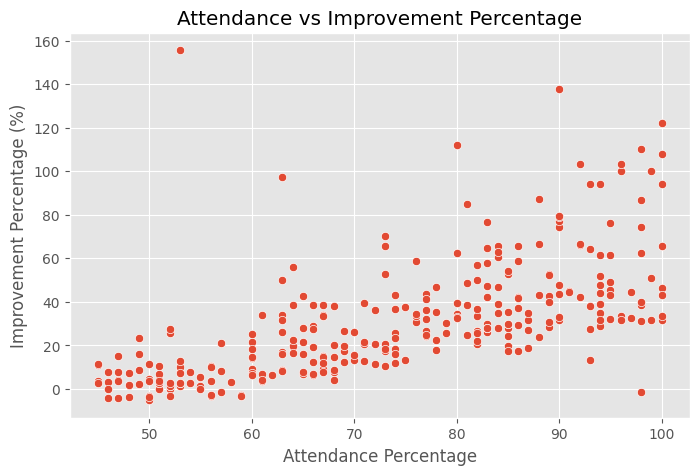

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Attendance_Percentage",
    y="Improvement_Percentage"
)

plt.title("Attendance vs Improvement Percentage")
plt.xlabel("Attendance Percentage")
plt.ylabel("Improvement Percentage (%)")

plt.show()

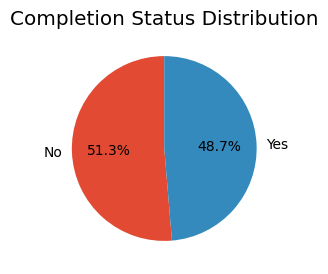

In [ ]:
completion_counts = (
    df["Completion_Status"]
    .value_counts()
)

plt.figure(figsize=(3,3))

plt.pie(
    completion_counts,
    labels=completion_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Completion Status Distribution")

plt.show()

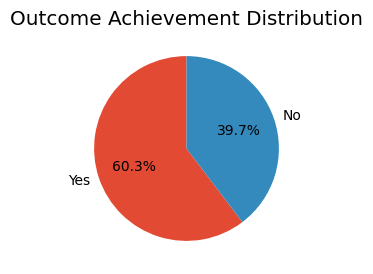

In [ ]:
outcome_counts = (
    df["Outcome_Achieved"]
    .value_counts()
)

plt.figure(figsize=(3,3))

plt.pie(
    outcome_counts,
    labels=outcome_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Outcome Achievement Distribution")

plt.show()

In [ ]:
successful = df[df["Outcome_Achieved"]=="Yes"]

cost_per_success = (
    successful["Program_Cost"].sum()
    /
    len(successful)
)

print(cost_per_success)

1689.5027624309391


In [ ]:
df.isnull().sum()

,0
Student_ID,0
Gender,0
Age,0
District,0
Program_Name,0
Attendance_Percentage,0
Pre_Test_Score,0
Post_Test_Score,0
Program_Cost,0
Enrollment_Date,0


In [ ]:
df.to_csv(
    "ngo_cleaned_data.csv",
    index=False
)

print("CSV saved successfully!")

CSV saved successfully!


In [ ]:
from google.colab import files

files.download("ngo_cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>